# 📡 Обнаружение дронов по RF-сигналам

**ВКР: Разработка системы обнаружения и распознавания дронов (RF-модуль)**

### Датасет
**Noisy Drone RF Signal Classification** (sgluege)  
- 7 классов: DJI, FutabaT14, FutabaT7, Graupner, Noise, Taranis, Turnigy  
- 26 уровней SNR (от -20 до +30 дБ)  
- ~98 705 сэмплов в одном `dataset.pt` (25 ГБ)

**Подключение:** Add Data → `noisy-drone-rf-signal-classification` (sgluege)

⚠️ Файл 25 ГБ — загружаем через memory-mapping, чтобы не забить RAM

In [1]:
import os, json, random, time, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

WORK_DIR = Path('/kaggle/working')
VIZ_DIR = WORK_DIR / 'visualizations'
MODEL_DIR = WORK_DIR / 'models'
for d in [VIZ_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
WD = 1e-4
PATIENCE = 8

CLASS_NAMES = ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
NUM_CLASSES = len(CLASS_NAMES)

print(f'✅ Классов: {NUM_CLASSES}  |  {CLASS_NAMES}')

PyTorch 2.10.0+cu128 | cuda
GPU: Tesla T4
✅ Классов: 7  |  ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']


---
## 1. Загрузка датасета

In [2]:
# Поиск dataset.pt
KAGGLE_INPUT = Path('/kaggle/input')
pt_files = list(KAGGLE_INPUT.rglob('dataset.pt'))

if not pt_files:
    pt_files = list(KAGGLE_INPUT.rglob('*.pt'))

print(f'📂 Найдено .pt файлов: {len(pt_files)}')
for f in pt_files:
    print(f'   {f} — {f.stat().st_size/1e9:.1f} GB')

PT_PATH = pt_files[0]
print(f'\n✅ Используем: {PT_PATH}')

# Читаем CSV-метаданные
for csv_name in ['class_stats.csv', 'SNR_stats.csv']:
    csv_path = PT_PATH.parent / csv_name
    if csv_path.exists():
        print(f'\n📄 {csv_name}:')
        print(pd.read_csv(csv_path).to_string(index=False))

📂 Найдено .pt файлов: 1
   /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt — 25.9 GB

✅ Используем: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt

📄 class_stats.csv:
 Unnamed: 0     class  class_int  count
          0       DJI          0   2194
          1 FutabaT14          1   6938
          2  FutabaT7          2   3661
          3  Graupner          3   6481
          4     Noise          4  52552
          5   Taranis          5  16546
          6   Turnigy          6  10333

📄 SNR_stats.csv:
 Unnamed: 0  SNR  count
          0  -20   3792
          1  -18   3795
          2  -16   3796
          3  -14   3796
          4  -12   3797
          5  -10   3796
          6   -8   3795
          7   -6   3795
          8   -4   3798
          9   -2   3798
         10    0   3798
         11    2   3795
         12    4   3798
         13    6   3794
         14    8   3796
         15   10   3800
         16   12   3798


In [3]:
# ============================================================
# Загрузка dataset.pt через memory-mapping
# ============================================================

print('⏳ Загрузка dataset.pt (mmap=True, может занять 1-2 мин)...')
t0 = time.time()

try:
    # PyTorch >= 2.1: mmap не загружает в RAM
    dataset_raw = torch.load(PT_PATH, map_location='cpu', weights_only=False, mmap=True)
    print(f'   ✅ Загружено через mmap за {time.time()-t0:.0f}с')
except TypeError:
    # Старая версия PyTorch без mmap
    print('   ⚠️ mmap не поддерживается, обычная загрузка...')
    dataset_raw = torch.load(PT_PATH, map_location='cpu', weights_only=False)
    print(f'   ✅ Загружено за {time.time()-t0:.0f}с')

# Исследуем структуру
print(f'\n📐 Тип: {type(dataset_raw)}')
if isinstance(dataset_raw, dict):
    for k, v in dataset_raw.items():
        if isinstance(v, torch.Tensor):
            print(f'   {k}: Tensor shape={v.shape} dtype={v.dtype}')
        elif isinstance(v, (list, np.ndarray)):
            print(f'   {k}: {type(v).__name__} len={len(v)}')
        else:
            print(f'   {k}: {type(v).__name__}')
elif isinstance(dataset_raw, (list, tuple)):
    print(f'   Длина: {len(dataset_raw)}')
    if len(dataset_raw) > 0:
        sample = dataset_raw[0]
        print(f'   Первый элемент: {type(sample)}')
        if isinstance(sample, dict):
            for k, v in sample.items():
                if hasattr(v, 'shape'): print(f'      {k}: shape={v.shape}')
                else: print(f'      {k}: {v}')
        elif isinstance(sample, (tuple, list)):
            for i, v in enumerate(sample):
                if hasattr(v, 'shape'): print(f'      [{i}]: shape={v.shape}')
                else: print(f'      [{i}]: {v}')
elif isinstance(dataset_raw, torch.Tensor):
    print(f'   Shape: {dataset_raw.shape}, dtype={dataset_raw.dtype}')

⏳ Загрузка dataset.pt (mmap=True, может занять 1-2 мин)...
   ✅ Загружено через mmap за 0с

📐 Тип: <class 'dict'>
   x_iq: Tensor shape=torch.Size([98705, 2, 16384]) dtype=torch.float32
   x_spec: Tensor shape=torch.Size([98705, 2, 128, 128]) dtype=torch.float32
   y: Tensor shape=torch.Size([98705]) dtype=torch.int64
   snr: Tensor shape=torch.Size([98705]) dtype=torch.int32
   duty_cycle: Tensor shape=torch.Size([98705]) dtype=torch.float32


In [4]:
# ============================================================
# Извлечение данных и меток (адаптируется под формат)
# ============================================================

X_data = None  # Тензор данных
Y_labels = None  # Метки классов
Y_snr = None  # SNR уровни

if isinstance(dataset_raw, dict):
    # Ищем данные по возможным ключам
    for k in ['data', 'x', 'X', 'x_iq', 'samples', 'spectrograms', 'features']:
        if k in dataset_raw and isinstance(dataset_raw[k], torch.Tensor):
            X_data = dataset_raw[k]
            print(f'   Данные: ключ="{k}", shape={X_data.shape}')
            break
    for k in ['labels', 'y', 'Y', 'targets', 'target', 'class']:
        if k in dataset_raw and isinstance(dataset_raw[k], torch.Tensor):
            Y_labels = dataset_raw[k]
            print(f'   Метки:  ключ="{k}", shape={Y_labels.shape}')
            break
    for k in ['snr', 'SNR', 'snr_db']:
        if k in dataset_raw and isinstance(dataset_raw[k], torch.Tensor):
            Y_snr = dataset_raw[k]
            print(f'   SNR:    ключ="{k}", shape={Y_snr.shape}')
            break
    
    # Если не нашли стандартные ключи — берём первые два тензора
    if X_data is None:
        tensors = [(k, v) for k, v in dataset_raw.items() if isinstance(v, torch.Tensor)]
        tensors.sort(key=lambda x: x[1].numel(), reverse=True)
        if len(tensors) >= 1:
            X_data = tensors[0][1]
            print(f'   Данные (auto): "{tensors[0][0]}", shape={X_data.shape}')
        if len(tensors) >= 2 and Y_labels is None:
            Y_labels = tensors[1][1]
            print(f'   Метки (auto):  "{tensors[1][0]}", shape={Y_labels.shape}')

elif isinstance(dataset_raw, (list, tuple)):
    # Список сэмплов
    print(f'   Формат: список из {len(dataset_raw)} сэмплов')
    # Собираем в тензоры
    sample = dataset_raw[0]
    if isinstance(sample, dict):
        x_key = [k for k in sample.keys() if 'x' in k.lower() or 'data' in k.lower() or 'iq' in k.lower()]
        y_key = [k for k in sample.keys() if 'y' in k.lower() or 'label' in k.lower() or 'target' in k.lower()]
        if x_key: print(f'   X ключ: {x_key[0]}, shape per sample: {sample[x_key[0]].shape}')
        if y_key: print(f'   Y ключ: {y_key[0]}')

if X_data is not None:
    print(f'\n📊 Итого:')
    print(f'   Сэмплов: {X_data.shape[0]}')
    print(f'   Форма сэмпла: {X_data.shape[1:]}')
    if Y_labels is not None:
        print(f'   Уникальных меток: {Y_labels.unique().tolist()}')
else:
    print('\n⚠️ Не удалось автоматически извлечь данные.')
    print('   Ключи dict:', list(dataset_raw.keys()) if isinstance(dataset_raw, dict) else 'не dict')

   Данные: ключ="x_iq", shape=torch.Size([98705, 2, 16384])
   Метки:  ключ="y", shape=torch.Size([98705])
   SNR:    ключ="snr", shape=torch.Size([98705])

📊 Итого:
   Сэмплов: 98705
   Форма сэмпла: torch.Size([2, 16384])
   Уникальных меток: [0, 1, 2, 3, 4, 5, 6]


---
## 2. EDA

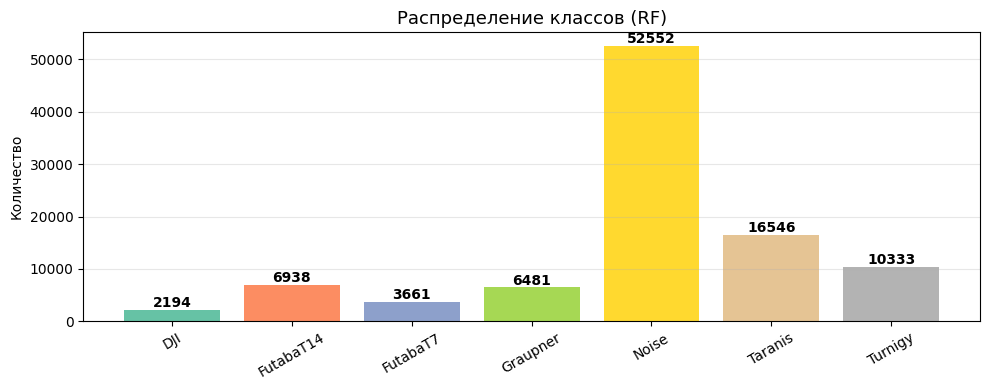

In [5]:
# Распределение классов
if Y_labels is not None:
    labels_np = Y_labels.numpy() if isinstance(Y_labels, torch.Tensor) else np.array(Y_labels)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    unique, counts = np.unique(labels_np, return_counts=True)
    names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in unique]
    colors = plt.cm.Set2(np.linspace(0, 1, len(unique)))
    bars = ax.bar(names, counts, color=colors)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, v+max(counts)*0.01,
                str(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title('Распределение классов (RF)', fontsize=13)
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(VIZ_DIR/'class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

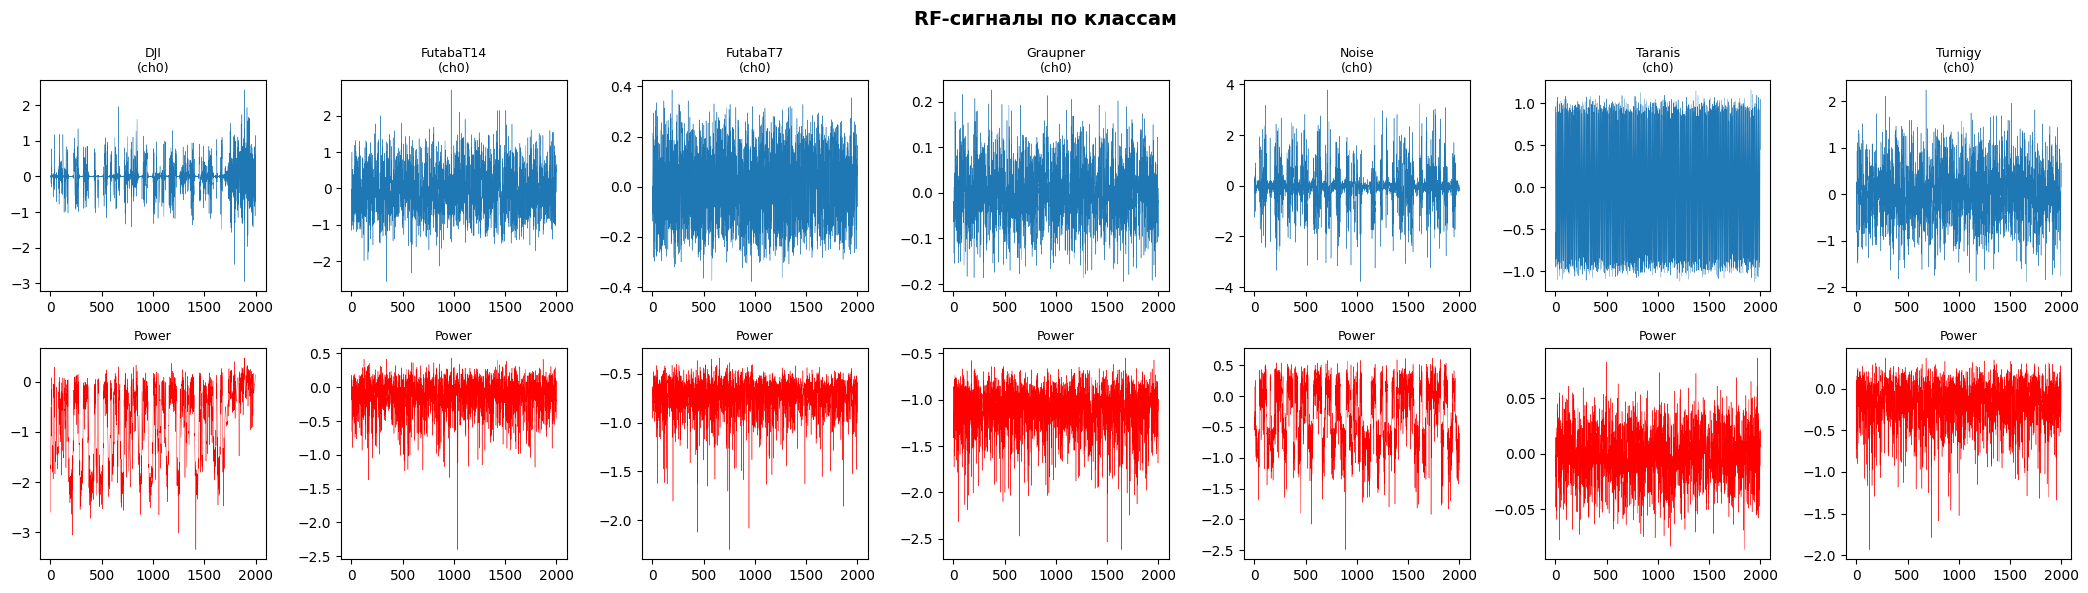

In [6]:
# Визуализация сэмплов
n_show = min(NUM_CLASSES, 7)
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))
if n_show == 1: axes = axes.reshape(-1, 1)

for i in range(n_show):
    # Находим первый сэмпл этого класса
    mask = (labels_np == i)
    idx = np.where(mask)[0][0]
    sample = X_data[idx]
    
    if sample.dim() == 1:
        # 1D сигнал
        axes[0, i].plot(sample[:2000].numpy(), linewidth=0.3)
        axes[0, i].set_title(f'{CLASS_NAMES[i]}\n(raw signal)', fontsize=9)
        # Спектр
        spec = np.abs(np.fft.fft(sample.numpy())[:len(sample)//2])
        axes[1, i].plot(spec[:500], linewidth=0.3, color='red')
        axes[1, i].set_title('FFT', fontsize=9)
    
    elif sample.dim() == 2:
        # 2D: (C, L) или (H, W)
        if sample.shape[0] <= 4:  # каналы
            axes[0, i].plot(sample[0, :2000].numpy(), linewidth=0.3)
            axes[0, i].set_title(f'{CLASS_NAMES[i]}\n(ch0)', fontsize=9)
            if sample.shape[0] >= 2:
                power = torch.log10(torch.sqrt(sample[0]**2 + sample[1]**2) + 1e-12)
                axes[1, i].plot(power[:2000].numpy(), linewidth=0.3, color='red')
                axes[1, i].set_title('Power', fontsize=9)
        else:
            # Уже спектрограмма (H, W)
            axes[0, i].imshow(sample.numpy(), aspect='auto', cmap='viridis')
            axes[0, i].set_title(f'{CLASS_NAMES[i]}', fontsize=9)
            axes[1, i].imshow(sample.numpy(), aspect='auto', cmap='hot')
            axes[1, i].set_title('hot cmap', fontsize=9)
    
    elif sample.dim() == 3:
        # 3D: (C, H, W) — спектрограмма
        img = sample[0].numpy() if sample.shape[0] <= 4 else sample.numpy().mean(0)
        axes[0, i].imshow(img, aspect='auto', cmap='viridis')
        axes[0, i].set_title(f'{CLASS_NAMES[i]}', fontsize=9)
        # Power
        if sample.shape[0] >= 2:
            power = torch.log10(torch.sqrt(sample[0]**2 + sample[1]**2) + 1e-12)
            axes[1, i].imshow(power.numpy(), aspect='auto', cmap='hot')
        else:
            axes[1, i].imshow(img, aspect='auto', cmap='hot')
        axes[1, i].set_title('Power/hot', fontsize=9)

plt.suptitle('RF-сигналы по классам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'rf_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Dataset и DataLoaders

In [7]:
# ============================================================
# Dataset: индексирует X_data и Y_labels по номеру
# ============================================================

class RFDataset(Dataset):
    def __init__(self, X, Y, indices, augment=False):
        self.X = X
        self.Y = Y
        self.indices = indices
        self.augment = augment
    
    def __len__(self): return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x = self.X[real_idx].float()
        y = int(self.Y[real_idx].item()) if isinstance(self.Y[real_idx], torch.Tensor) else int(self.Y[real_idx])
        
        # Убеждаемся что есть batch-dim для каналов
        if x.dim() == 1:
            x = x.unsqueeze(0)  # (1, L)
        
        # Нормализация
        x = (x - x.mean()) / (x.std() + 1e-8)
        
        if self.augment:
            if torch.rand(1).item() < 0.3:
                x = x + torch.randn_like(x) * 0.05
            if torch.rand(1).item() < 0.5:
                x = x.flip(-1)
        
        return x, torch.tensor(y, dtype=torch.long)


# ============================================================
# Подвыборка если датасет слишком большой (>30K на класс)
# ============================================================

MAX_PER_CLASS = 5000  # Берём не более N сэмплов на класс для скорости

all_indices = []
for cls_id in range(NUM_CLASSES):
    cls_mask = (labels_np == cls_id)
    cls_indices = np.where(cls_mask)[0]
    if len(cls_indices) > MAX_PER_CLASS:
        np.random.seed(SEED)
        cls_indices = np.random.choice(cls_indices, MAX_PER_CLASS, replace=False)
    all_indices.extend(cls_indices.tolist())

np.random.seed(SEED)
np.random.shuffle(all_indices)
sub_labels = labels_np[all_indices]

print(f'📊 Подвыборка: {len(all_indices)} из {len(labels_np)} (max {MAX_PER_CLASS}/класс)')
for i in range(NUM_CLASSES):
    print(f'   [{i}] {CLASS_NAMES[i]:12s}: {(sub_labels==i).sum()}')

# Split
train_idx, test_idx = train_test_split(range(len(all_indices)), test_size=0.15,
                                        stratify=sub_labels, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.18,
                                       stratify=sub_labels[train_idx], random_state=SEED)

train_real = [all_indices[i] for i in train_idx]
val_real = [all_indices[i] for i in val_idx]
test_real = [all_indices[i] for i in test_idx]

print(f'\n   Train: {len(train_real)} | Val: {len(val_real)} | Test: {len(test_real)}')

train_ds = RFDataset(X_data, Y_labels, train_real, augment=True)
val_ds = RFDataset(X_data, Y_labels, val_real)
test_ds = RFDataset(X_data, Y_labels, test_real)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

bx, by = next(iter(train_loader))
print(f'\n   Batch: {bx.shape}  labels: {by[:8].tolist()}')
SAMPLE_SHAPE = bx.shape[1:]  # (C, ...) 
IN_CH = bx.shape[1]
print(f'   IN_CH={IN_CH}, sample_shape={SAMPLE_SHAPE}')

📊 Подвыборка: 30855 из 98705 (max 5000/класс)
   [0] DJI         : 2194
   [1] FutabaT14   : 5000
   [2] FutabaT7    : 3661
   [3] Graupner    : 5000
   [4] Noise       : 5000
   [5] Taranis     : 5000
   [6] Turnigy     : 5000

   Train: 21505 | Val: 4721 | Test: 4629

   Batch: torch.Size([32, 2, 16384])  labels: [1, 5, 1, 6, 1, 3, 0, 6]
   IN_CH=2, sample_shape=torch.Size([2, 16384])


---
## 4. Модели

In [8]:
# ============================================================
# Выбор архитектуры в зависимости от формы входа
# ============================================================

if len(SAMPLE_SHAPE) == 2:
    # (C, L) — 1D сигнал → Conv1D модели
    print(f'📐 Вход: 1D сигнал {SAMPLE_SHAPE} → используем Conv1D')
    
    class RFCNN1D(nn.Module):
        def __init__(self, in_ch, nc):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(in_ch, 32, 7, stride=2, padding=3), nn.BatchNorm1d(32), nn.ReLU(True),
                nn.Conv1d(32, 64, 5, stride=2, padding=2), nn.BatchNorm1d(64), nn.ReLU(True),
                nn.Conv1d(64, 128, 5, stride=2, padding=2), nn.BatchNorm1d(128), nn.ReLU(True),
                nn.Conv1d(128, 256, 3, stride=2, padding=1), nn.BatchNorm1d(256), nn.ReLU(True),
                nn.AdaptiveAvgPool1d(16),
            )
            self.head = nn.Sequential(
                nn.Flatten(), nn.Linear(256*16, 256), nn.ReLU(True),
                nn.Dropout(0.5), nn.Linear(256, nc),
            )
        def forward(self, x): return self.head(self.conv(x))
    
    class RFResNet1D(nn.Module):
        def __init__(self, in_ch, nc):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv1d(in_ch, 64, 7, stride=2, padding=3), nn.BatchNorm1d(64), nn.ReLU(True),
                nn.MaxPool1d(3, stride=2, padding=1),
            )
            self.layer1 = self._make_block(64, 64)
            self.layer2 = self._make_block(64, 128, stride=2)
            self.layer3 = self._make_block(128, 256, stride=2)
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.5), nn.Linear(256, nc),
            )
        def _make_block(self, in_c, out_c, stride=1):
            downsample = None
            if stride != 1 or in_c != out_c:
                downsample = nn.Sequential(nn.Conv1d(in_c, out_c, 1, stride=stride), nn.BatchNorm1d(out_c))
            return nn.Sequential(
                _ResBlock1D(in_c, out_c, stride, downsample),
                _ResBlock1D(out_c, out_c),
            )
        def forward(self, x):
            return self.head(self.layer3(self.layer2(self.layer1(self.stem(x)))))
    
    class _ResBlock1D(nn.Module):
        def __init__(self, in_c, out_c, stride=1, downsample=None):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(in_c, out_c, 3, stride=stride, padding=1), nn.BatchNorm1d(out_c), nn.ReLU(True),
                nn.Conv1d(out_c, out_c, 3, padding=1), nn.BatchNorm1d(out_c),
            )
            self.downsample = downsample
        def forward(self, x):
            identity = self.downsample(x) if self.downsample else x
            return F.relu(self.conv(x) + identity)
    
    class RFMLP(nn.Module):
        def __init__(self, input_size, nc):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input_size, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.3),
                nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(True), nn.Dropout(0.4),
                nn.Linear(256, nc),
            )
        def forward(self, x): return self.net(x)
    
    flat_size = IN_CH * SAMPLE_SHAPE[-1]
    MODEL_CONFIGS = [
        ('RF-CNN-1D', RFCNN1D(IN_CH, NUM_CLASSES)),
        ('RF-ResNet-1D', RFResNet1D(IN_CH, NUM_CLASSES)),
        ('RF-MLP', RFMLP(flat_size, NUM_CLASSES)),
    ]

else:
    # (C, H, W) — 2D спектрограмма → Conv2D
    print(f'📐 Вход: 2D спектрограмма {SAMPLE_SHAPE} → используем Conv2D')
    
    class RFCNN2D(nn.Module):
        def __init__(self, in_ch, nc):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(in_ch,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(0.2),
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.MaxPool2d(2), nn.Dropout2d(0.2),
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
                nn.AdaptiveAvgPool2d(4),
            )
            self.head = nn.Sequential(
                nn.Flatten(), nn.Linear(128*4*4, 256), nn.ReLU(True),
                nn.Dropout(0.5), nn.Linear(256, nc),
            )
        def forward(self, x): return self.head(self.features(x))
    
    class RFResBlock2D(nn.Module):
        def __init__(self, ch):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
                nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch))
        def forward(self, x): return F.relu(self.block(x)+x)
    
    class RFResNet2D(nn.Module):
        def __init__(self, in_ch, nc):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
                RFResBlock2D(64), nn.MaxPool2d(2),
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
                RFResBlock2D(128), nn.MaxPool2d(2),
                nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
                nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.5),
            )
            self.head = nn.Linear(256, nc)
        def forward(self, x): return self.head(self.net(x))
    
    class RFMLP(nn.Module):
        def __init__(self, input_size, nc):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input_size, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.3),
                nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(True), nn.Dropout(0.4),
                nn.Linear(256, nc),
            )
        def forward(self, x): return self.net(x)
    
    flat_size = 1
    for s in SAMPLE_SHAPE: flat_size *= s
    MODEL_CONFIGS = [
        ('RF-CNN-2D', RFCNN2D(IN_CH, NUM_CLASSES)),
        ('RF-ResNet-2D', RFResNet2D(IN_CH, NUM_CLASSES)),
        ('RF-MLP', RFMLP(flat_size, NUM_CLASSES)),
    ]

# Проверка
for name, m in MODEL_CONFIGS:
    p = sum(p.numel() for p in m.parameters())
    o = m(bx[:2])
    print(f'   {name:16s}: {p/1e3:.1f}K params, out={o.shape}')

📐 Вход: 1D сигнал torch.Size([2, 16384]) → используем Conv1D
   RF-CNN-1D       : 1202.0K params, out=torch.Size([2, 7])
   RF-ResNet-1D    : 959.7K params, out=torch.Size([2, 7])
   RF-MLP          : 16912.4K params, out=torch.Size([2, 7])


---
## 5. Обучение

In [9]:
def train_model(model, tl, vl, epochs=EPOCHS, lr=LR, patience=PATIENCE, name='model'):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WD)
    sch = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    hist = {'tl':[],'vl':[],'ta':[],'va':[],'vf':[]}
    best_f1, wait, best_st = 0., 0, None
    
    for ep in range(epochs):
        model.train()
        ls, c, t = 0., 0, 0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); o = model(x); l = crit(o,y); l.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
            ls += l.item()*x.size(0); c += (o.argmax(1)==y).sum().item(); t += y.size(0)
        sch.step()
        model.eval()
        vls, ps, ys = 0., [], []
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                o = model(x); vls += crit(o,y).item()*x.size(0)
                ps.extend(o.argmax(1).cpu().numpy()); ys.extend(y.cpu().numpy())
        tl_v,ta_v = ls/t, c/t
        vl_v = vls/len(ys); va_v = accuracy_score(ys,ps); vf_v = f1_score(ys,ps,average='macro')
        for k,v in [('tl',tl_v),('vl',vl_v),('ta',ta_v),('va',va_v),('vf',vf_v)]: hist[k].append(v)
        if vf_v > best_f1:
            best_f1, wait = vf_v, 0
            best_st = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save(model.state_dict(), MODEL_DIR/f'{name}_best.pt')
        else: wait += 1
        if (ep+1)%5==0 or ep==0:
            print(f'  Ep {ep+1:3d}/{epochs} │ loss={tl_v:.4f} acc={ta_v:.4f} │ v_loss={vl_v:.4f} v_acc={va_v:.4f} F1={vf_v:.4f}')
        if wait >= patience:
            print(f'  ⏹️ Early stop (ep {ep+1})'); break
    if best_st: model.load_state_dict(best_st); model = model.to(DEVICE)
    print(f'  ✅ Best F1: {best_f1:.4f}')
    return model, hist

In [10]:
all_models, all_hists, model_names = [], [], []
for name, model in MODEL_CONFIGS:
    print(f'\n🚀 {name}')
    print('='*70)
    m, h = train_model(model, train_loader, val_loader, name=name.lower().replace(' ','_'))
    all_models.append(m)
    all_hists.append(h)
    model_names.append(name)


🚀 RF-CNN-1D
  Ep   1/40 │ loss=1.5941 acc=0.3881 │ v_loss=1.3481 v_acc=0.5094 F1=0.4327
  Ep   5/40 │ loss=1.1577 acc=0.5700 │ v_loss=1.0332 v_acc=0.6181 F1=0.5970
  Ep  10/40 │ loss=0.9841 acc=0.6420 │ v_loss=0.8919 v_acc=0.6842 F1=0.6922
  Ep  15/40 │ loss=0.8533 acc=0.6978 │ v_loss=0.7735 v_acc=0.7320 F1=0.7430
  Ep  20/40 │ loss=0.7795 acc=0.7270 │ v_loss=0.7153 v_acc=0.7520 F1=0.7670
  Ep  25/40 │ loss=0.7197 acc=0.7488 │ v_loss=0.7009 v_acc=0.7615 F1=0.7754
  Ep  30/40 │ loss=0.6667 acc=0.7652 │ v_loss=0.6592 v_acc=0.7757 F1=0.7878
  Ep  35/40 │ loss=0.6399 acc=0.7773 │ v_loss=0.6350 v_acc=0.7850 F1=0.7994
  Ep  40/40 │ loss=0.6261 acc=0.7815 │ v_loss=0.6295 v_acc=0.7901 F1=0.8040
  ✅ Best F1: 0.8040

🚀 RF-ResNet-1D
  Ep   1/40 │ loss=1.4593 acc=0.4452 │ v_loss=1.2866 v_acc=0.4675 F1=0.4796
  Ep   5/40 │ loss=0.9117 acc=0.6797 │ v_loss=0.9467 v_acc=0.6422 F1=0.6553
  Ep  10/40 │ loss=0.7733 acc=0.7361 │ v_loss=0.9575 v_acc=0.6327 F1=0.6548
  Ep  15/40 │ loss=0.6948 acc=0.7640 │ 

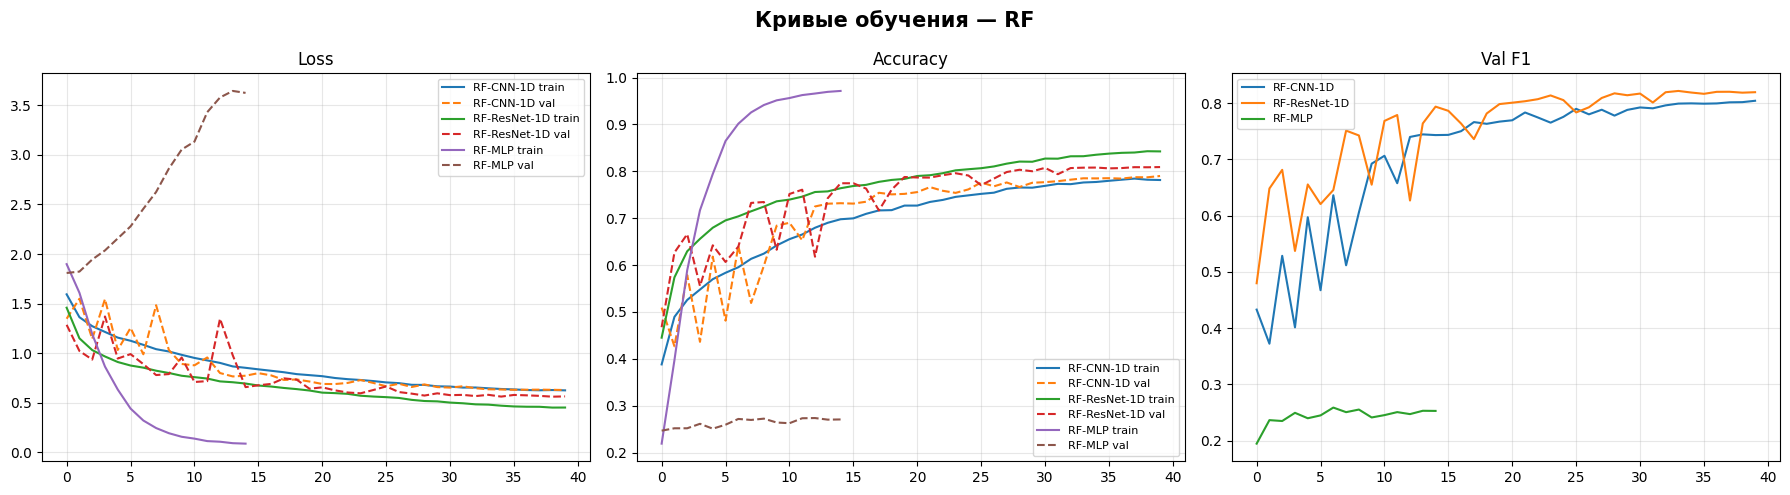

In [11]:
# Кривые обучения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for h, n in zip(all_hists, model_names):
    axes[0].plot(h['tl'],label=f'{n} train'); axes[0].plot(h['vl'],'--',label=f'{n} val')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
for h, n in zip(all_hists, model_names):
    axes[1].plot(h['ta'],label=f'{n} train'); axes[1].plot(h['va'],'--',label=f'{n} val')
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
for h, n in zip(all_hists, model_names): axes[2].plot(h['vf'],label=n)
axes[2].set_title('Val F1'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.suptitle('Кривые обучения — RF', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Оценка

In [12]:
def evaluate(model, loader, name):
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            o = model(x.to(DEVICE))
            ps.extend(o.argmax(1).cpu().numpy()); ys.extend(y.numpy())
    ps, ys = np.array(ps), np.array(ys)
    acc = accuracy_score(ys, ps); f1 = f1_score(ys, ps, average='macro')
    print(f'\n{"="*50}\n📊 {name} | Acc={acc:.4f} F1={f1:.4f}\n{"="*50}')
    print(classification_report(ys, ps, target_names=CLASS_NAMES))
    return {'model': name, 'accuracy': acc, 'f1': f1, 'preds': ps, 'labels': ys}

all_res = []
for m, n in zip(all_models, model_names):
    all_res.append(evaluate(m, test_loader, n))


📊 RF-CNN-1D | Acc=0.8000 F1=0.8116
              precision    recall  f1-score   support

         DJI       0.93      0.69      0.80       329
   FutabaT14       0.94      0.73      0.82       750
    FutabaT7       0.87      0.73      0.79       550
    Graupner       0.96      0.81      0.88       750
       Noise       0.50      0.95      0.65       750
     Taranis       0.96      0.86      0.91       750
     Turnigy       0.95      0.75      0.84       750

    accuracy                           0.80      4629
   macro avg       0.87      0.79      0.81      4629
weighted avg       0.87      0.80      0.81      4629


📊 RF-ResNet-1D | Acc=0.8226 F1=0.8335
              precision    recall  f1-score   support

         DJI       0.96      0.74      0.84       329
   FutabaT14       0.97      0.77      0.86       750
    FutabaT7       0.92      0.75      0.83       550
    Graupner       0.93      0.80      0.86       750
       Noise       0.54      0.97      0.69       750
   

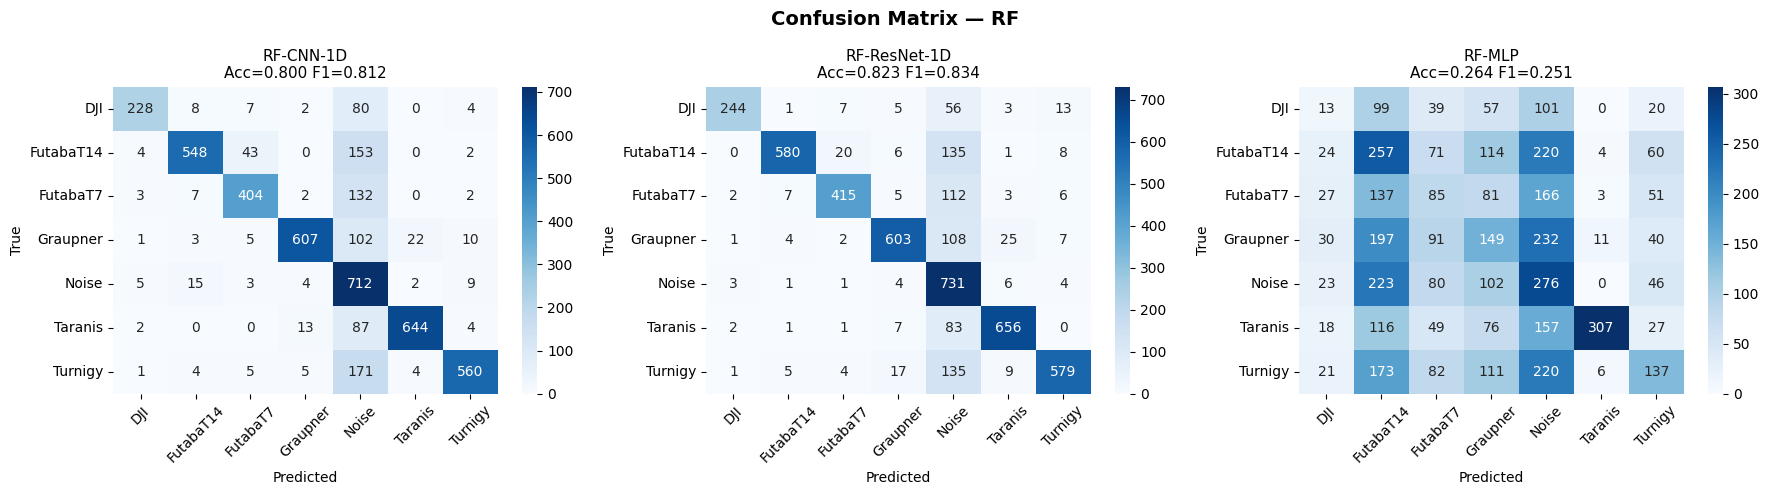

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, len(all_res), figsize=(6*len(all_res), 5))
if len(all_res) == 1: axes = [axes]
for i, r in enumerate(all_res):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[i].set_title(f"{r['model']}\nAcc={r['accuracy']:.3f} F1={r['f1']:.3f}", fontsize=11)
    axes[i].set_ylabel('True'); axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Confusion Matrix — RF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Сравнение и экспорт

In [14]:
def bench(model, n=200):
    model.eval()
    x = bx[:1].to(DEVICE)
    with torch.no_grad():
        for _ in range(20): model(x)
    ts = []
    with torch.no_grad():
        for _ in range(n):
            t0=time.perf_counter(); model(x)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            ts.append(time.perf_counter()-t0)
    return np.mean(ts)*1000

rows = []
for model, res, nm in zip(all_models, all_res, model_names):
    p = sum(p.numel() for p in model.parameters())
    ms = bench(model)
    rows.append({'Модель': nm, 'Accuracy': f"{res['accuracy']:.4f}",
                 'F1': f"{res['f1']:.4f}", 'ms': f'{ms:.2f}', 'Params(K)': f'{p/1e3:.1f}'})

cmp = pd.DataFrame(rows)
print('📊 Сравнение:')
display(cmp)
cmp.to_csv(VIZ_DIR/'rf_comparison.csv', index=False)

📊 Сравнение:


,Модель,Accuracy,F1,ms,Params(K)
0,RF-CNN-1D,0.8000,0.8116,0.95,1202.0
1,RF-ResNet-1D,0.8226,0.8335,2.40,959.7
2,RF-MLP,0.2644,0.2509,0.38,16912.4


In [15]:
best_idx = int(np.argmax([r['f1'] for r in all_res]))
best = all_res[best_idx]
summary = {
    'task': f'7-class RF drone classification',
    'dataset': 'Noisy Drone RF Signal Classification (sgluege)',
    'classes': CLASS_NAMES,
    'input_shape': str(list(SAMPLE_SHAPE)),
    'max_per_class': MAX_PER_CLASS,
    'total_used': len(all_indices),
    'train': len(train_real), 'val': len(val_real), 'test': len(test_real),
    'best_model': best['model'],
    'best_accuracy': f"{best['accuracy']:.4f}",
    'best_f1': f"{best['f1']:.4f}",
}
print('\n'+'='*50)
print('📋 СВОДКА ДЛЯ ВКР (RF-модуль)')
print('='*50)
for k,v in summary.items(): print(f'  {k:18s}: {v}')
with open(VIZ_DIR/'rf_summary.json','w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'\n💾 Kaggle: Output → Download All')


📋 СВОДКА ДЛЯ ВКР (RF-модуль)
  task              : 7-class RF drone classification
  dataset           : Noisy Drone RF Signal Classification (sgluege)
  classes           : ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
  input_shape       : [2, 16384]
  max_per_class     : 5000
  total_used        : 30855
  train             : 21505
  val               : 4721
  test              : 4629
  best_model        : RF-ResNet-1D
  best_accuracy     : 0.8226
  best_f1           : 0.8335

💾 Kaggle: Output → Download All
